#### Original loop

In [2]:
 #for each sigma in [.01,.05,.10,.20,.30], multiply by 256, could be 4 and 30 for now
    # for image in images (by images we mean frame variable as defined below, should be 90 constant frames, each image has 90 frames)
        # for each noise each time we add noise (implement with another for loop, we need 1000 iterations(at first do 100, 200)), 
            #    make sure in range (0,256)
            # for each scan
                # collect prediction output
                # concat. outputs for different scans
            # concat response outputs, collect shape
            # shape should be (1000, 90, number neurons) (call this response_shape), where 90 is number of frames (could be 15 30 etc)
        # concat all the response_shape objects together, shape will be (number of images, 1000, 90, num neurons)
        # calc. sum spike count over 90, shape should be (number images, 1000, number neurons)
        
        # calc. mean over 1000, shape should be (number images, number neurons)
        # calc. var over 1000, shape should be (number images, number neurons)
        # plot mean vs var
        # calc. fano factor var over mean
        # plot fano factor dist. as histogram

#### Environment

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, linregress
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units


#### meeting with anton, july 1

- fix code
    - eliminate mean as parameter, will always be 0
- for future ref., output from for loop should include brain region
- send same 30 neurons, each for sigma 3 15 30 
    - dynamic and constant
- send histograms of responses
- plot LR and smoothing curve
- annotate plots with CI and slope of LR
- later send plots of fano factor as well
- if can't find neuron id's within a few hours then reach out to ralf/anton

plots (overarching goal is we want to characterize by brain area, for now remind ralf that we are looking at a mix)
- histograms of individual neurons responses for an image with varying noise, illustrates variability in response created by input noise
- scatter plot of mean sigma and var sigma, divide by first value for each neuron as anton showed
- scatter plot of var mean relationship, includes all neurons and all images
    - mean is average response of a neuron to same image with varying noise 
- fano factor histogram, for a real neuron ff around 1 and we want to see how artifical neurons differ (d, c, and then by sigma)
    - pick sigma value with ff closest to 1
- pseudo poisson parameters histograms, two plots (one each), illustrates pseudo poisson dist. and how it is different from poisson

#### july 1 (plot_select30_hist() here as well)

NOTE: say on plots that these histograms DO NOT indicate which region of the brain the neuron is in

In [2]:
import matplotlib.ticker as ticker
def plot_select30_hist(array, title, neurons):
    neuron_pvalue = pd.DataFrame({
    'neuron' : [],
    'p_value' :[]
    })

    fig, axes = plt.subplots(5,6, figsize = (20,6))

    p_values = np.empty((neurons.size))
    test_statistics = np.empty((neurons.size))
    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = np.sum(array[:,:,neuron], axis = 1).flatten()
        ax.hist(plot, color = 'g')
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{round(x,3)}"))

        # hypothesis test
        p_value, test_statistic = shapiro(plot)
        p_values[id] = p_value
        test_statistics[id] = test_statistic
        neuron_pvalue.loc[id] = neuron, p_value

    # display histogram
    fig.suptitle(f"Neuron Outputs: {title}")
    fig.supxlabel('Predicted Firing Rate')
    fig.supylabel('Counts')
    plt.tight_layout()
    plt.show()

    # print dataframe with p values
    neuron_pvalue['neuron'] = neuron_pvalue['neuron'].astype(int)
    neuron_pvalue['p_value'] = neuron_pvalue['p_value'].round(3)
    print(neuron_pvalue)

    #print("For the following neurons: \n",neurons)
    #print("Value counts for p > alpha of 0.05, which would indicate that the graphs do show a gaussian distribution.",np.unique(p_values > 0.05, return_counts = True))


#### new prediction loop

In [ ]:
# noise_type can be "constant", "dynamic", or "no noise"
# image is a single image
# sigma is a single sigma
# ex. input would be predict_loop("dynamic", image1, 3)
def predict_loop(noise_type, noise_seeds, image, sigma):

# check here if input scans is 1d or 2d

# in order to minimize storage, pre allocate array sizes 
    num_neurons = 7493 # navigate to scans.csv and calculate
    num_frames = image.shape[0] 

        # results for each time we add noise
    noise_results = np.empty((noise_seeds, num_frames, num_neurons)) 

    for noise_i in range(noise_seeds):
                
        # need to generate new noise every iteration 
        
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')

        sessions_scans = [[4,7]] # just one scan

        # make predictions for one noise seed
        for pair in sessions_scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [6]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

In [7]:
dynamic3 = predict_loop("dynamic", 100, frames, 3)

In [10]:
dynamic3.shape

(100, 15, 7493)

In [16]:
rand_neurons = np.random.randint(0,7493, size = 30)
type(rand_neurons)

numpy.ndarray

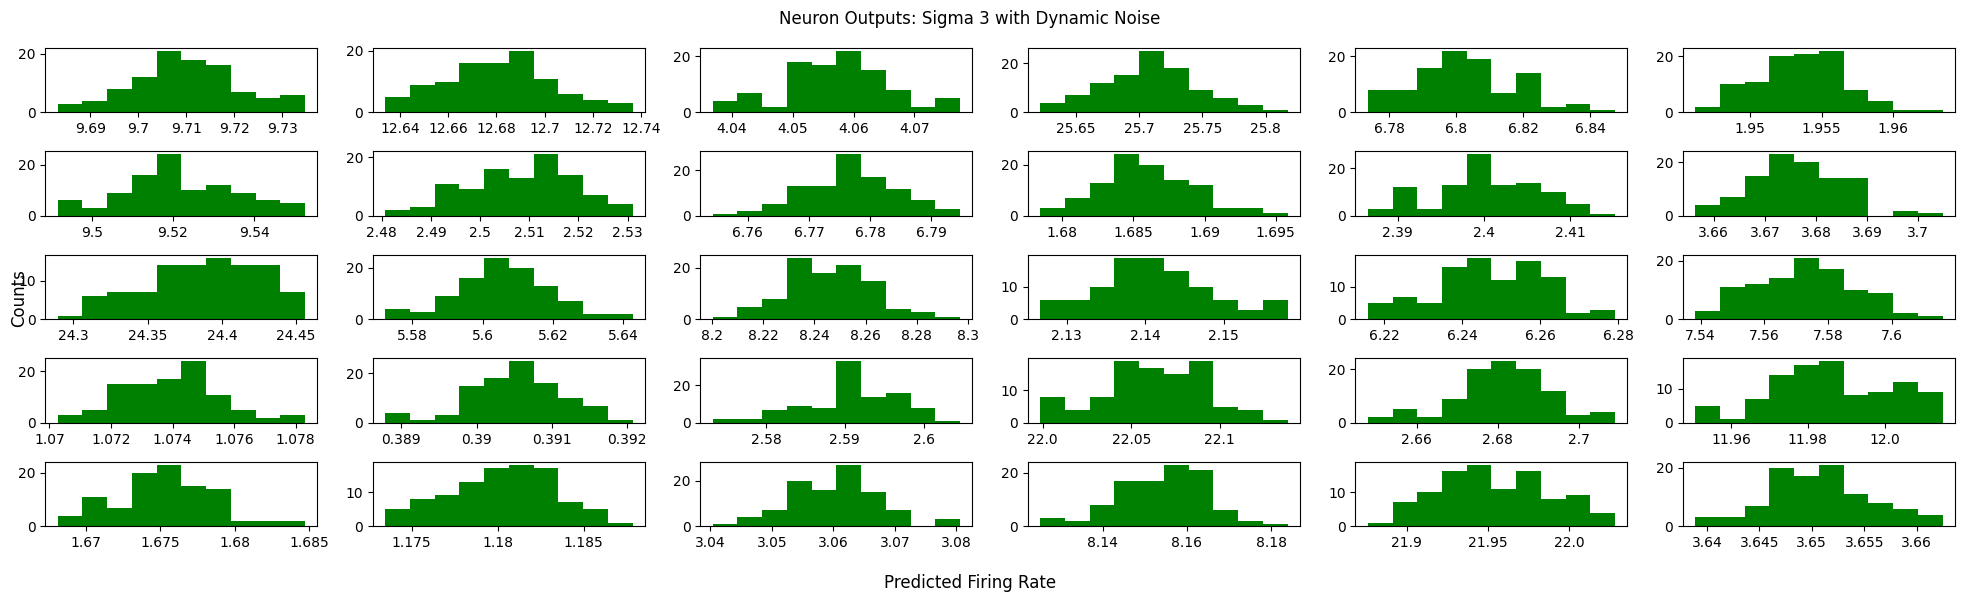

    neuron  p_value
0     5688    0.991
1      603    0.989
2     6035    0.987
3     6053    0.993
4     4126    0.984
5       11    0.991
6     5904    0.984
7     2788    0.983
8     3056    0.994
9     4610    0.991
10     127    0.987
11    6733    0.991
12    6346    0.973
13    1698    0.994
14    6029    0.995
15    1392    0.981
16    5543    0.986
17    4781    0.990
18    7342    0.985
19     732    0.987
20    6288    0.970
21    2307    0.988
22    2952    0.987
23    4749    0.977
24    5667    0.990
25    7049    0.989
26    2157    0.988
27     522    0.991
28    2759    0.986
29     619    0.991


In [81]:
plot_select30_hist(dynamic3, "Sigma 3 with Dynamic Noise", rand_neurons)

In [ ]:
dynamic15 = predict_loop("dynamic", 100, frames, 15)
dyanmic30 = predict_loop("dynamic", 100, frames, 30)

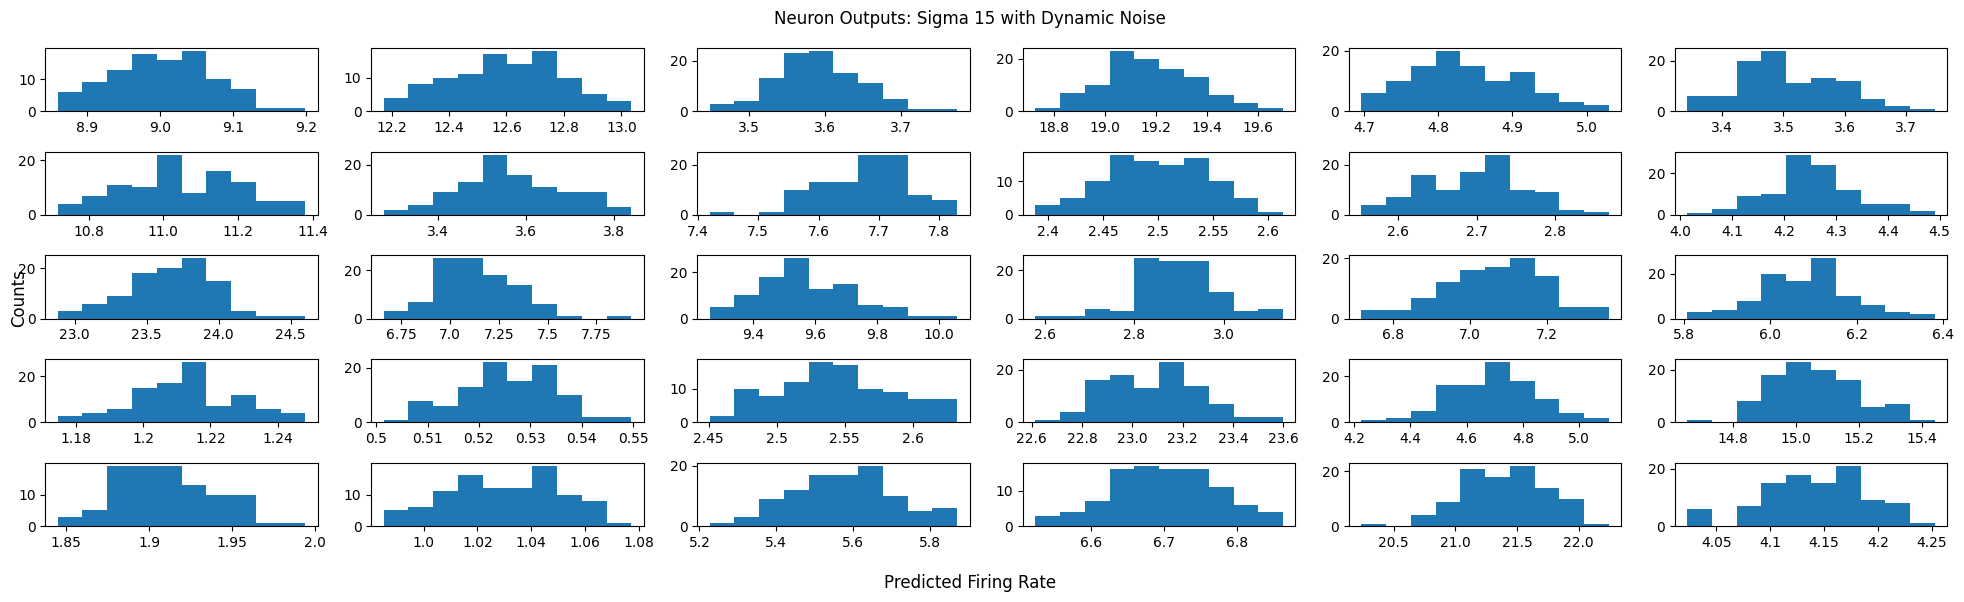

    neuron  p_value
0     5688    0.992
1      603    0.991
2     6035    0.985
3     6053    0.990
4     4126    0.985
5       11    0.979
6     5904    0.987
7     2788    0.990
8     3056    0.980
9     4610    0.993
10     127    0.985
11    6733    0.989
12    6346    0.990
13    1698    0.978
14    6029    0.978
15    1392    0.979
16    5543    0.990
17    4781    0.994
18    7342    0.991
19     732    0.993
20    6288    0.981
21    2307    0.985
22    2952    0.997
23    4749    0.988
24    5667    0.989
25    7049    0.981
26    2157    0.994
27     522    0.992
28    2759    0.985
29     619    0.986


In [61]:
plot_select30_hist(dynamic15, "Sigma 15 with Dynamic Noise", rand_neurons)

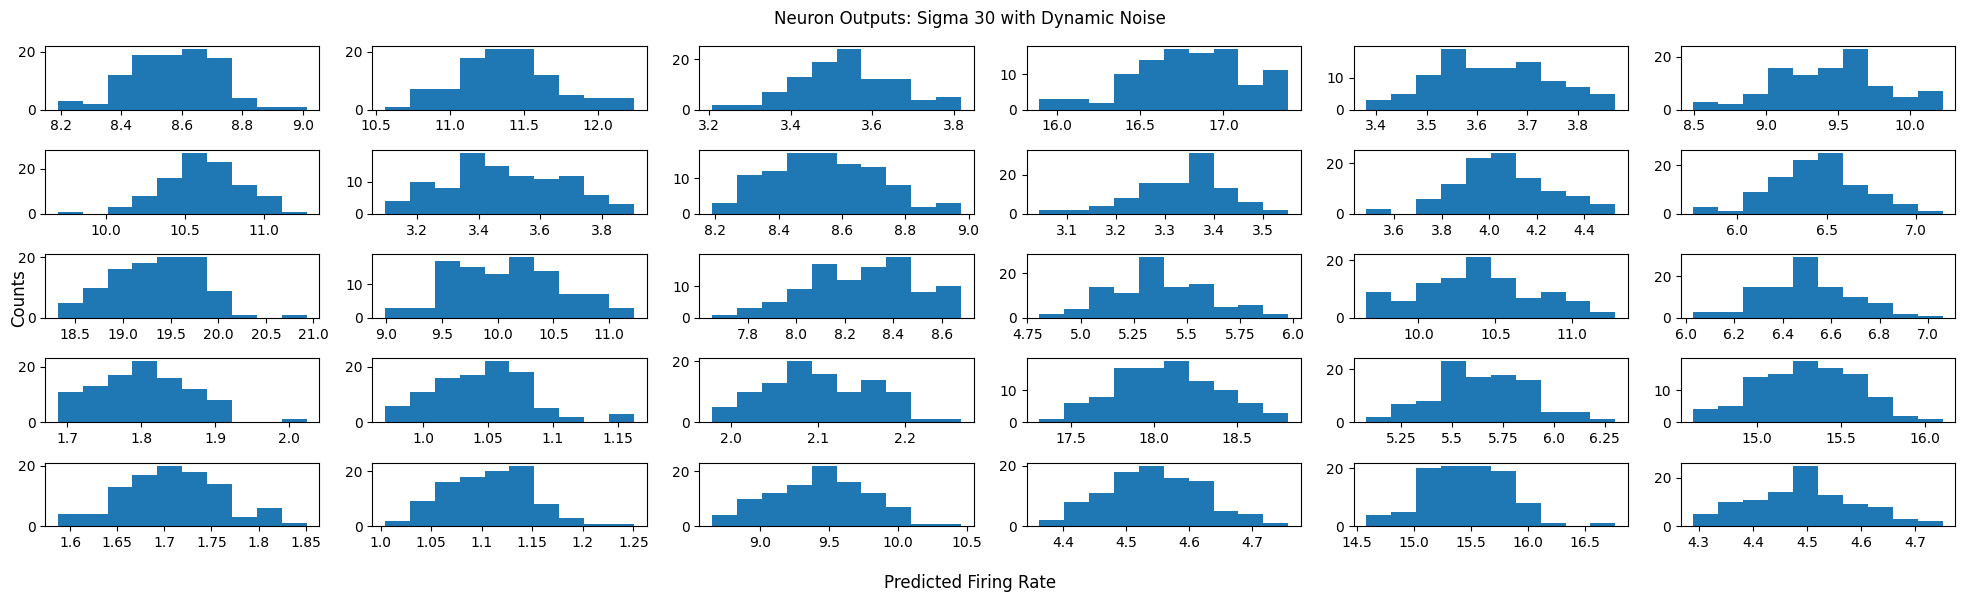

    neuron  p_value
0     5688    0.989
1      603    0.984
2     6035    0.993
3     6053    0.979
4     4126    0.987
5       11    0.988
6     5904    0.988
7     2788    0.981
8     3056    0.985
9     4610    0.979
10     127    0.986
11    6733    0.986
12    6346    0.987
13    1698    0.984
14    6029    0.982
15    1392    0.994
16    5543    0.982
17    4781    0.994
18    7342    0.976
19     732    0.967
20    6288    0.983
21    2307    0.994
22    2952    0.995
23    4749    0.993
24    5667    0.994
25    7049    0.989
26    2157    0.992
27     522    0.994
28    2759    0.986
29     619    0.989


In [62]:
dynamic30 = dyanmic30
plot_select30_hist(dynamic30, "Sigma 30 with Dynamic Noise", rand_neurons)

In [86]:
constant3 = predict_loop("constant", 100, frames, 3)
constant15 = predict_loop("constant", 100, frames, 15)
constant30 = predict_loop("constant", 100, frames, 30 )

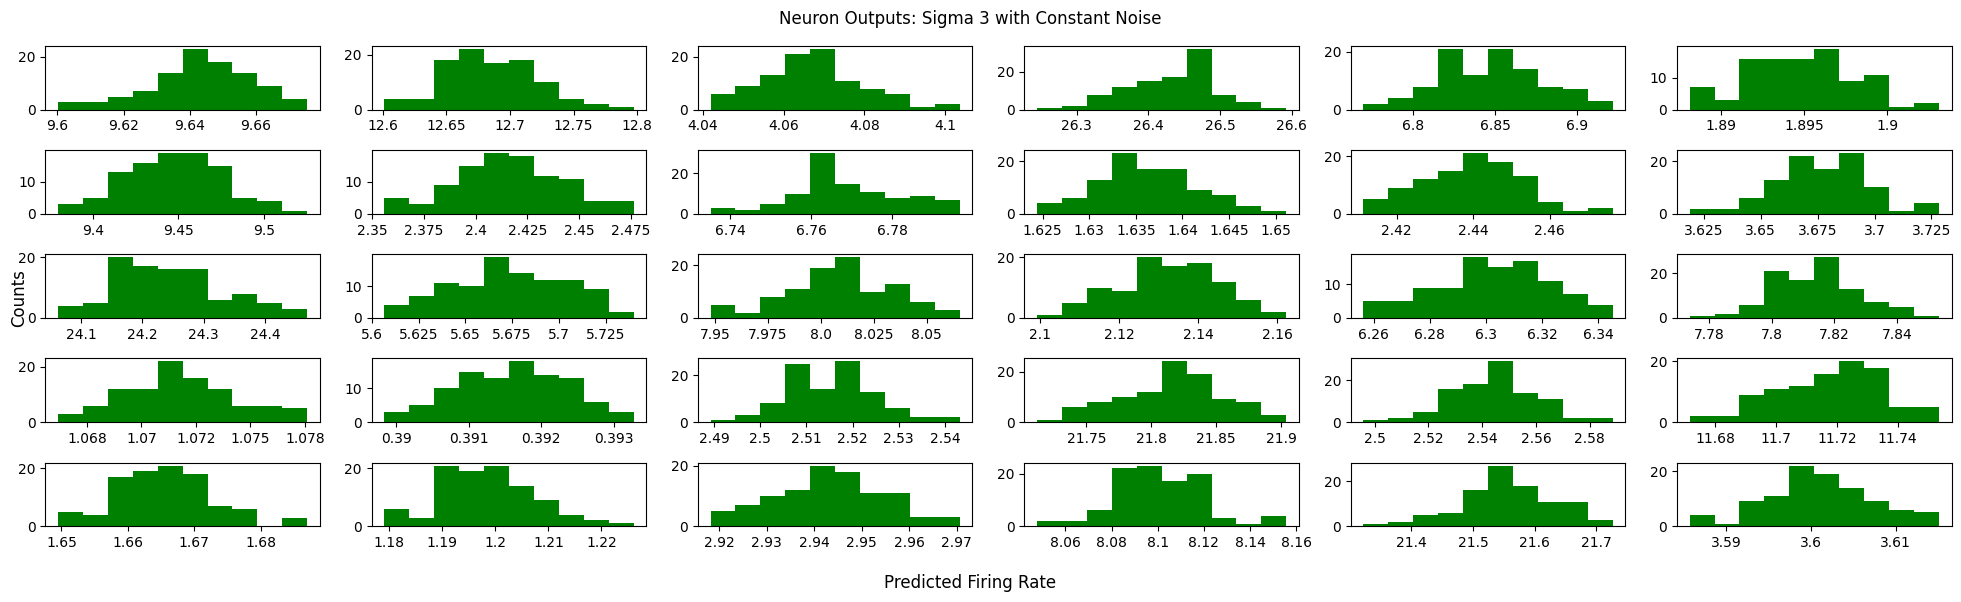

    neuron  p_value
0     5688    0.983
1      603    0.991
2     6035    0.987
3     6053    0.981
4     4126    0.992
5       11    0.992
6     5904    0.994
7     2788    0.993
8     3056    0.979
9     4610    0.993
10     127    0.990
11    6733    0.991
12    6346    0.978
13    1698    0.980
14    6029    0.985
15    1392    0.994
16    5543    0.987
17    4781    0.994
18    7342    0.988
19     732    0.989
20    6288    0.986
21    2307    0.990
22    2952    0.993
23    4749    0.985
24    5667    0.985
25    7049    0.988
26    2157    0.990
27     522    0.978
28    2759    0.988
29     619    0.991


In [90]:
plot_select30_hist(constant3, "Sigma 3 with Constant Noise", rand_neurons)

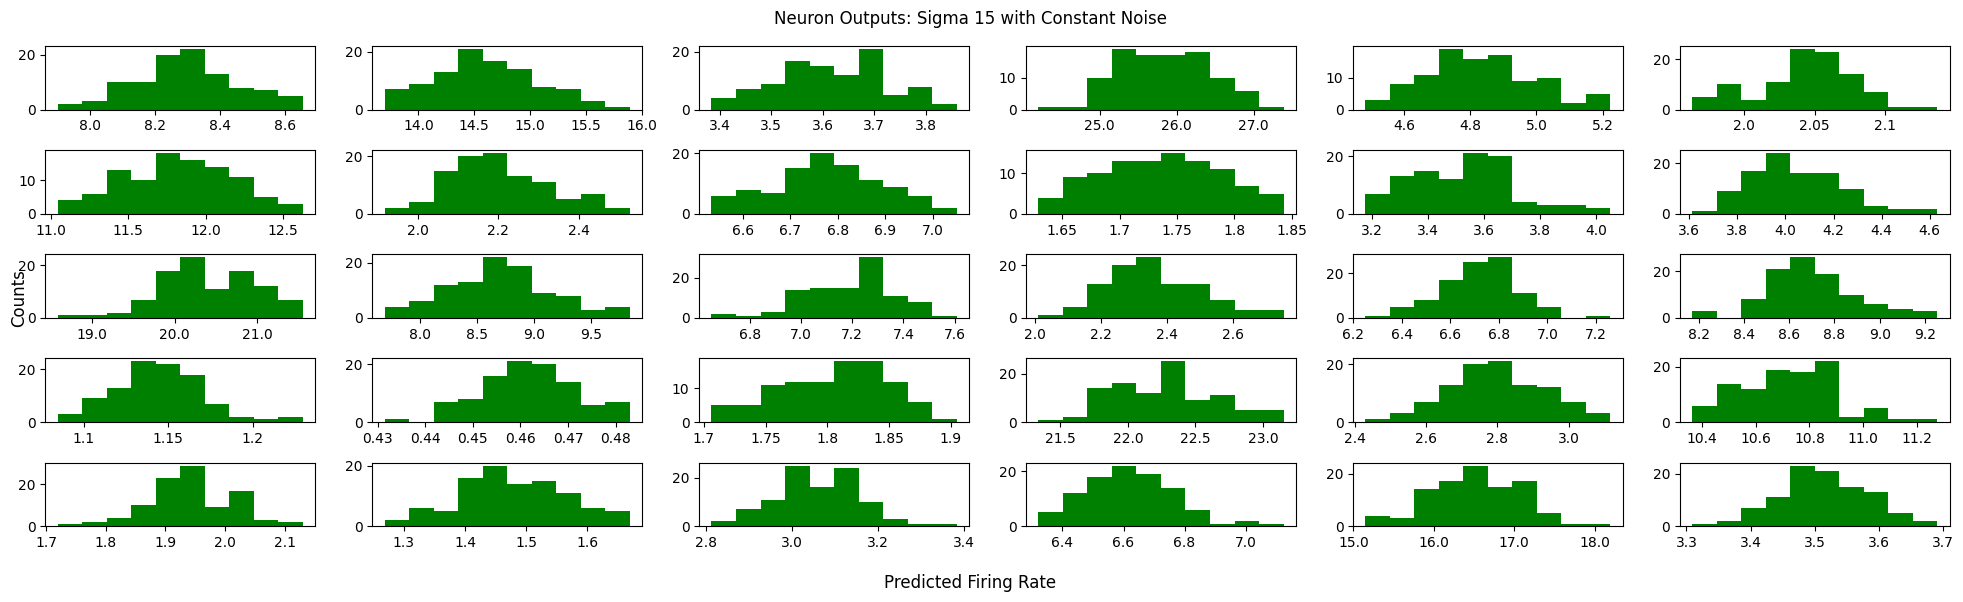

    neuron  p_value
0     5688    0.994
1      603    0.988
2     6035    0.988
3     6053    0.991
4     4126    0.989
5       11    0.978
6     5904    0.991
7     2788    0.977
8     3056    0.990
9     4610    0.986
10     127    0.977
11    6733    0.980
12    6346    0.984
13    1698    0.989
14    6029    0.973
15    1392    0.983
16    5543    0.981
17    4781    0.976
18    7342    0.975
19     732    0.991
20    6288    0.983
21    2307    0.982
22    2952    0.994
23    4749    0.984
24    5667    0.990
25    7049    0.992
26    2157    0.989
27     522    0.983
28    2759    0.994
29     619    0.995


In [91]:
plot_select30_hist(constant15, "Sigma 15 with Constant Noise", rand_neurons)

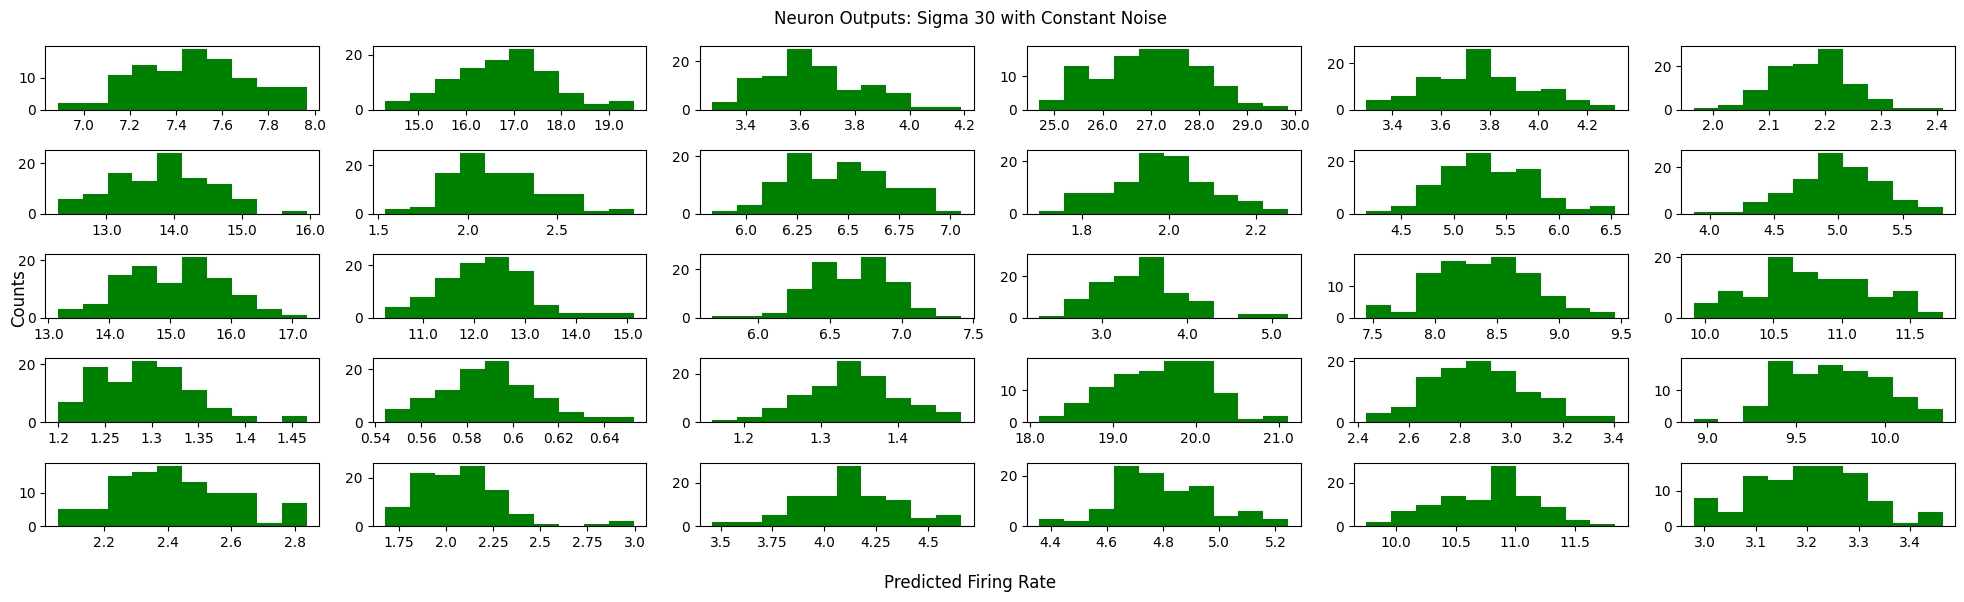

    neuron  p_value
0     5688    0.987
1      603    0.992
2     6035    0.976
3     6053    0.990
4     4126    0.987
5       11    0.992
6     5904    0.990
7     2788    0.980
8     3056    0.982
9     4610    0.990
10     127    0.989
11    6733    0.992
12    6346    0.989
13    1698    0.974
14    6029    0.988
15    1392    0.958
16    5543    0.992
17    4781    0.983
18    7342    0.965
19     732    0.987
20    6288    0.991
21    2307    0.992
22    2952    0.991
23    4749    0.985
24    5667    0.982
25    7049    0.906
26    2157    0.989
27     522    0.982
28    2759    0.989
29     619    0.985


In [92]:
plot_select30_hist(constant30, "Sigma 30 with Constant Noise", rand_neurons)

In [93]:
import pandas as pd

# Paste your neuron and p_value lists from the three outputs here:
neurons = [
    5688, 603, 6035, 6053, 4126, 11, 5904, 2788, 3056, 4610,
    127, 6733, 6346, 1698, 6029, 1392, 5543, 4781, 7342, 732,
    6288, 2307, 2952, 4749, 5667, 7049, 2157, 522, 2759, 619
]

pval_3 = [
    0.983, 0.991, 0.987, 0.981, 0.992, 0.992, 0.994, 0.993, 0.979, 0.993,
    0.990, 0.991, 0.978, 0.980, 0.985, 0.994, 0.987, 0.994, 0.988, 0.989,
    0.986, 0.990, 0.993, 0.985, 0.985, 0.988, 0.990, 0.978, 0.988, 0.991
]

pval_30 = [
    0.987, 0.992, 0.976, 0.990, 0.987, 0.992, 0.990, 0.980, 0.982, 0.990,
    0.989, 0.992, 0.989, 0.974, 0.988, 0.958, 0.992, 0.983, 0.965, 0.987,
    0.991, 0.992, 0.991, 0.985, 0.982, 0.906, 0.989, 0.982, 0.989, 0.985
]

pval_15 = [
    0.994, 0.988, 0.988, 0.991, 0.989, 0.978, 0.991, 0.977, 0.990, 0.986,
    0.977, 0.980, 0.984, 0.989, 0.973, 0.983, 0.981, 0.976, 0.975, 0.991,
    0.983, 0.982, 0.994, 0.984, 0.990, 0.992, 0.989, 0.983, 0.994, 0.995
]

# Create DataFrame
df = pd.DataFrame({
    'label': range(1, len(neurons)+1),
    'neuron': neurons,
    'sigma_3': pval_3,
    'sigma_15': pval_15,
    'sigma_30': pval_30
})

# Write to Excel
df.to_excel('constant_noise_neuron_pvalues.xlsx', index=False)

#### adding scans as parameter

In [7]:
# noise_type can be "constant", "dynamic", or "no noise"
# image is a single image
# sigma is a single sigma
# ex. input would be predict_loop("dynamic", image1, 3)
def predict_loop(noise_type, noise_seeds, image, sigma, scans):
    scans = ensure_2d_list(scans)
# in order to minimize storage, pre allocate array sizes 
    num_neurons = get_neuron_units(scans) # navigate to scans.csv and calculate
    num_frames = image.shape[0] 

        # results for each time we add noise
    noise_results = np.empty((noise_seeds, num_frames, num_neurons)) 
    for noise_i in range(noise_seeds):
                
        # need to generate new noise every iteration 
        
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')
        # make predictions for one noise seed
        for pair in scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [8]:
scans_csv = os.path.join(os.getcwd(),"data\\microns\\scans.csv")
scans_df = pd.read_csv(scans_csv)

In [9]:
scans_df.head()

,session,scan_idx,units,data_id
0,4,7,7493,232ba7ad384c7b93f58842b51e7e1ef6
1,5,6,8592,98a58d55e28951a38cc61cfec7d63f76
2,5,7,8138,6dea1dbe556674b1ebd8f984edd102c0
3,6,2,8158,45dc6cb6ed757fb223cdfa846060a2bf
4,6,4,8221,c947b82486ab3d4dfd2972e21ad2ce3b


In [52]:
test_scans = [[5,7], [4,7], [6,4], [6,2]]

scans_csv = os.path.join(os.getcwd(),"data\\microns\\scans.csv")
scans_df = pd.read_csv(scans_csv)
final_df = pd.DataFrame({}, columns = ['session', 'scan_idx', 'units', 'data_id'])
for scan in test_scans:
    row = scans_df[(scans_df['session'] == scan[0]) & (scans_df['scan_idx'] == scan[1])]
    final_df = pd.concat([final_df, row])
print(final_df['units'].sum())

32010


In [3]:
frames_1 = full(shape=[15, 144, 256], dtype="uint8", fill_value=128)
frames_1.shape

(15, 144, 256)

In [12]:
test = predict_loop("constant", 1, frames_1, 3, [[4,7], [5,7]])

In [13]:
test.shape

(1, 15, 15631)

#### july 3

In [3]:
def predict_loop(noise_type, noise_seeds, image, sigma, scans):
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    image: object
        image that we are adding noise to and then predicting on, ie like the frames object below
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    
    Returns
    -------
    array
        returns array with predictions for all neurons
    
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    scans = ensure_2d_list(scans)
    num_neurons = get_neuron_units(scans)
    num_frames = image.shape[0]

    noise_results = np.empty((noise_seeds, num_frames, num_neurons))

    for noise_i in range(noise_seeds):
                    
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')
        for pair in scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 being chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [6]:
frames_1 = full(shape=[15, 144, 256], dtype="uint8", fill_value=128)

In [5]:
test_pred = predict_loop("dynamic", 10, frames_1, 3, [[4,7]])
test_pred.shape

NameError: name 'frames_1' is not defined

#### July 7th

In [7]:
neurons = pd.read_excel("july 1st predictions//neuron_pvalues.xlsx")

In [6]:
neurons.head()

,label,neuron,sigma_3,sigma_15,sigma_30
0,1,5688,0.991,0.992,0.989
1,2,603,0.989,0.991,0.984
2,3,6035,0.987,0.985,0.993
3,4,6053,0.993,0.990,0.979
4,5,4126,0.984,0.985,0.987


In [8]:
neurons_ids = neurons['neuron']

In [11]:
neurons_ids

0     5688
1      603
2     6035
3     6053
4     4126
5       11
6     5904
7     2788
8     3056
9     4610
10     127
11    6733
12    6346
13    1698
14    6029
15    1392
16    5543
17    4781
18    7342
19     732
20    6288
21    2307
22    2952
23    4749
24    5667
25    7049
26    2157
27     522
28    2759
29     619
Name: neuron, dtype: int64

In [9]:
dynamic30 = predict_loop("dynamic", 100, frames_1, 30, [[4,7]])
dynamic15 = predict_loop("dynamic", 100, frames_1, 15, [[4,7]])
dynamic3 = predict_loop("dynamic", 100, frames_1, 3, [[4,7]])
constant30 = predict_loop("constant", 100, frames_1, 30, [[4,7]])
constant15 = predict_loop("constant", 100, frames_1, 15, [[4,7]])
constant3 = predict_loop("constant", 100, frames_1, 3, [[4,7]])

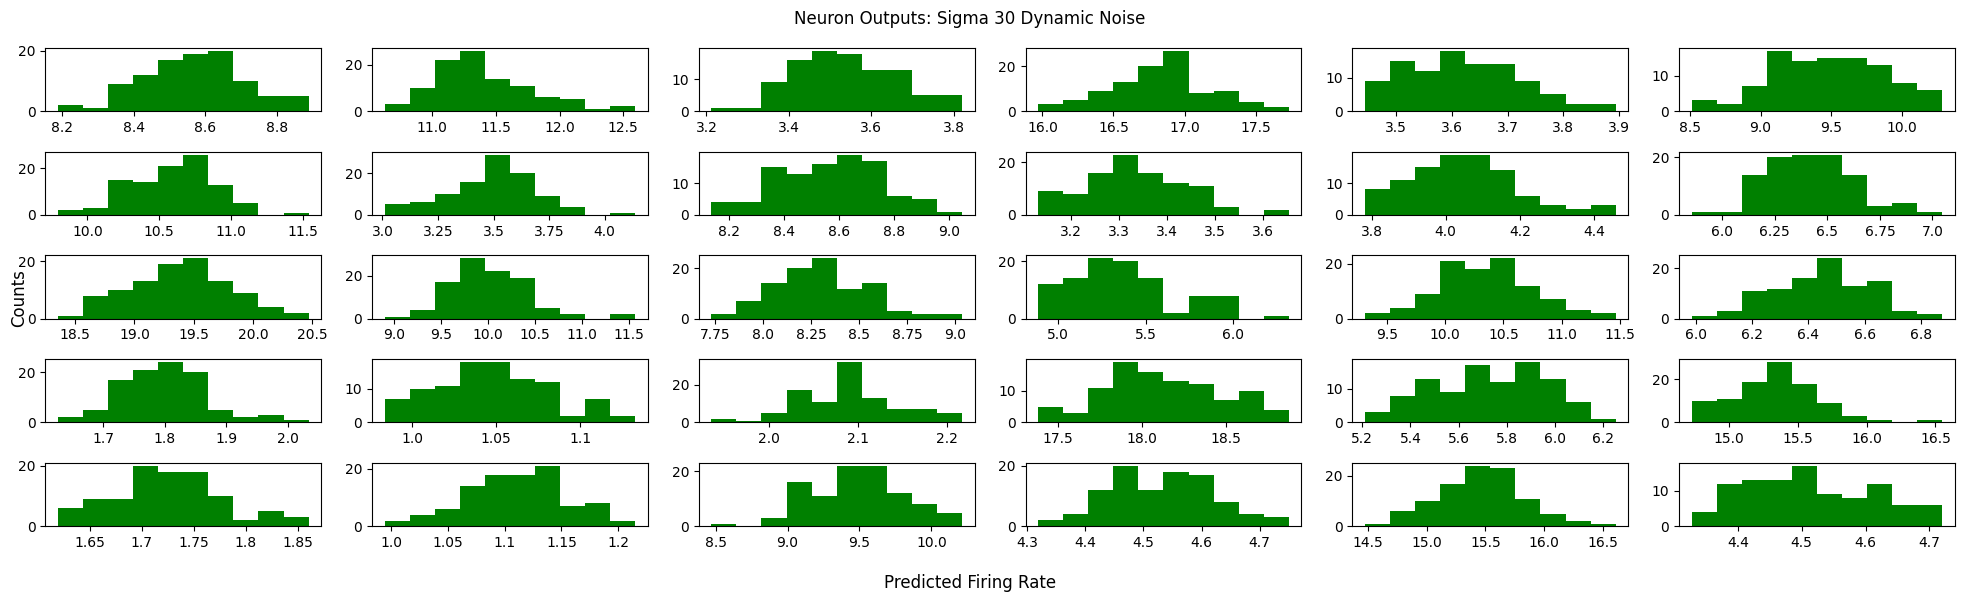

    neuron  p_value
0     5688    0.991
1      603    0.958
2     6035    0.988
3     6053    0.995
4     4126    0.975
5       11    0.986
6     5904    0.985
7     2788    0.982
8     3056    0.995
9     4610    0.987
10     127    0.981
11    6733    0.984
12    6346    0.990
13    1698    0.963
14    6029    0.982
15    1392    0.959
16    5543    0.992
17    4781    0.993
18    7342    0.981
19     732    0.981
20    6288    0.983
21    2307    0.983
22    2952    0.981
23    4749    0.974
24    5667    0.981
25    7049    0.995
26    2157    0.989
27     522    0.993
28    2759    0.993
29     619    0.974


In [15]:
plot_select30_hist(dynamic30, "Sigma 30 Dynamic Noise", neurons_ids)

In [16]:
dynamic30.shape

(100, 15, 7493)

In [17]:
dynamic30[:,:,619].shape

(100, 15)

In [41]:
print(np.mean(np.sum(dynamic30[:,:,0], axis = 1)))

36.56064570426941


In [1]:
def line_plot_mean(array, neurons):
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.mean(np.sum(array[:,:,neuron], axis = 1))
        final_array[i] = avg
    return final_array

In [17]:
mean_d30 = line_plot_mean(dynamic30, [i for i in range(100)])
mean_d15 = line_plot_mean(dynamic15, [i for i in range(100)])
mean_d3 = line_plot_mean(dynamic3, [i for i in range(100)])
mean_c30 = line_plot_mean(constant30, [i for i in range(100)])
mean_c15 = line_plot_mean(constant15, [i for i in range(100)])
mean_c3 = line_plot_mean(constant3, [i for i in range(100)])

In [15]:
len(mean_d30)

30

C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\1543894901.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\1543894901.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


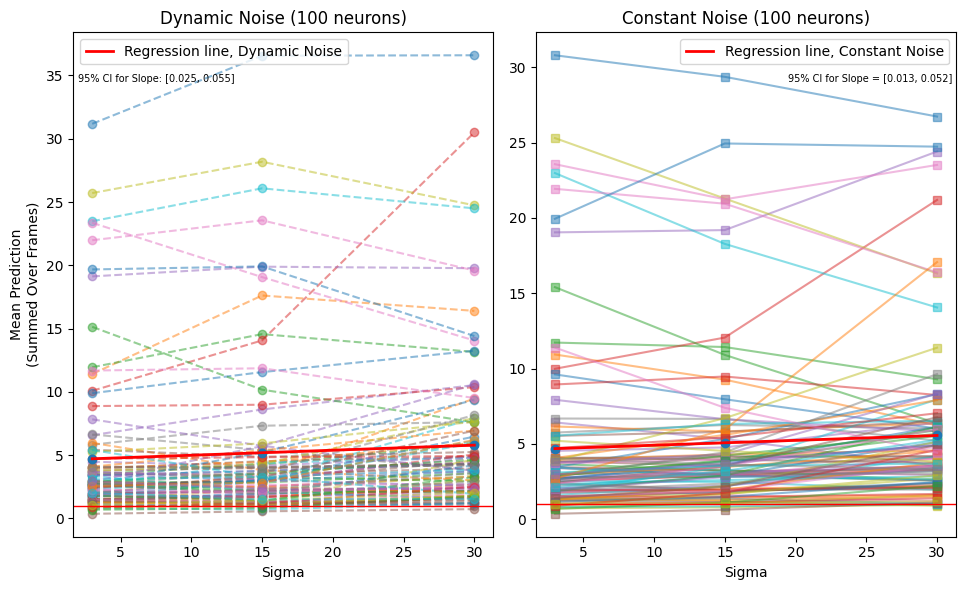

In [56]:
fig, axes = plt.subplots(1,2, figsize = (10,6))

sigmas = np.array([3, 15, 30])

# Mean values for dynamic and constant noise
dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

# Plot for each neuron
for i in range(100):  # 100 neurons
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]]
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]]

    # Plot dynamic noise
    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='--', alpha=0.5)

    # Plot constant noise
    axes[1].plot(sigmas, constant_y, marker='s', linestyle='-', alpha=0.5)
    
dynamic_mean_y = np.mean(dynamic_means, axis=1)   
constant_mean_y = np.mean(constant_means, axis=1)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


# regression line
# dynamic
axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

# constant
axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 34.5, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(19.5, 29, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='red', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='red', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma')
axes[0].set_title('Dynamic Noise (100 neurons)')
axes[1].set_title('Constant Noise (100 neurons)')
axes[0].set_ylabel('Mean Prediction\n(Summed Over Frames)')
axes[1].set_xlabel('Sigma')
axes[0].legend(loc = 'upper left')
axes[1].legend(loc = 'upper right')
plt.tight_layout()
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\1531625819.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\1531625819.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


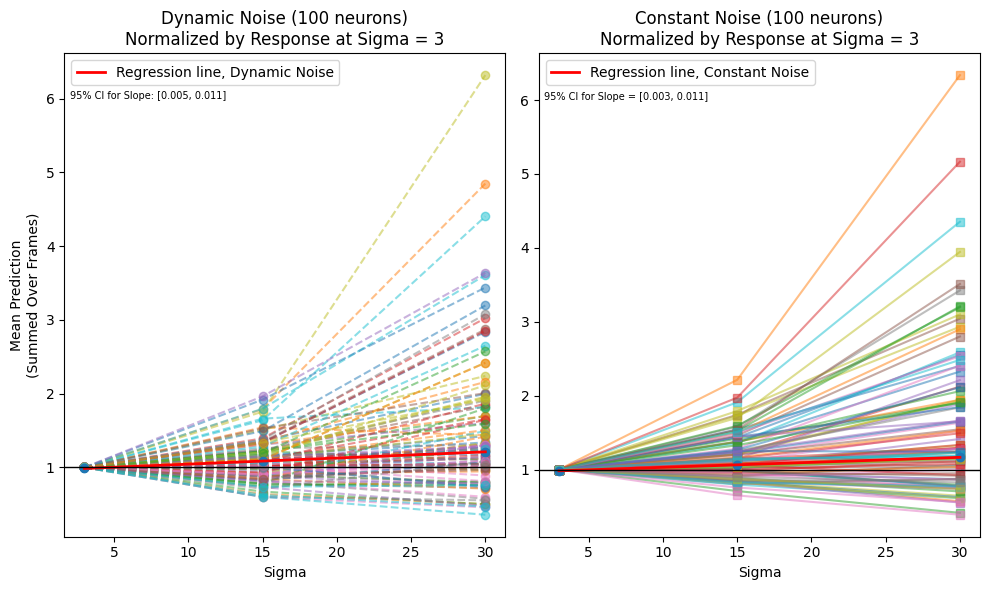

In [55]:
fig, axes = plt.subplots(1,2, figsize = (10,6))

sigmas = np.array([3, 15, 30])

# Mean values for dynamic and constant noise
dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

# Plot for each neuron
for i in range(100):  # 100 neurons
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] / mean_c3[i]
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] / mean_d3[i]

    # Plot dynamic noise
    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='--', alpha=0.5)

    # Plot constant noise
    axes[1].plot(sigmas, constant_y, marker='s', linestyle='-', alpha=0.5)
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


# regression line
# dynamic
axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

# constant
axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 6, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 6, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Response at Sigma = 3')
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Response at Sigma = 3')
axes[0].set_ylabel('Mean Prediction\n(Summed Over Frames)')
axes[1].set_xlabel('Sigma')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

#### july 9 - var/mean vs sigma plot

C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\3532377036.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'black', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_42732\3532377036.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'black', linewidth = 2)


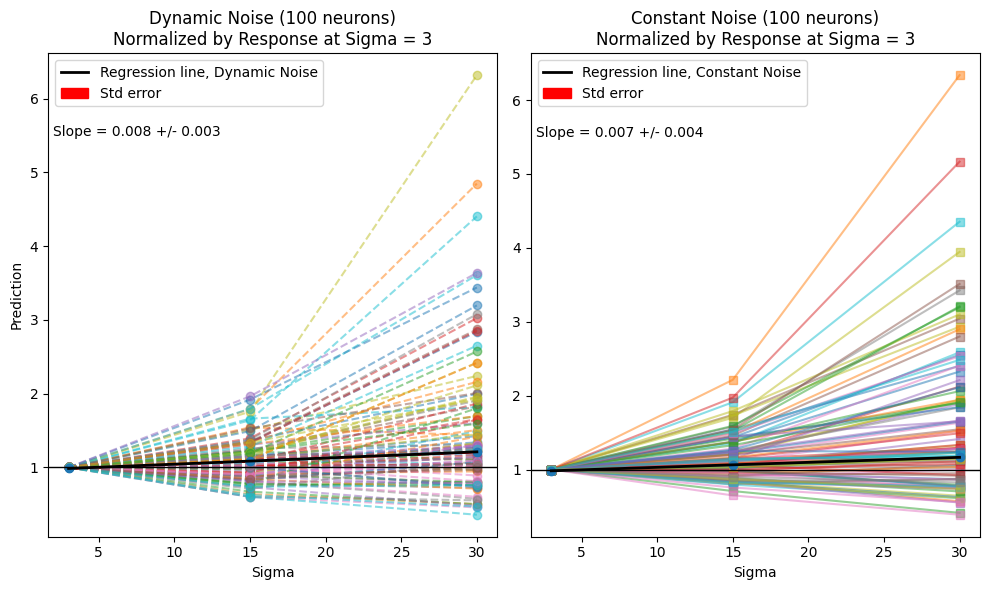

In [18]:
fig, axes = plt.subplots(1,2, figsize = (10,6))

sigmas = np.array([3, 15, 30])

# Mean values for dynamic and constant noise
dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

# Plot for each neuron
for i in range(100):  # 100 neurons
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] / mean_c3[i]
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] / mean_d3[i]

    # Plot dynamic noise
    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='--', alpha=0.5)

    # Plot constant noise
    axes[1].plot(sigmas, constant_y, marker='s', linestyle='-', alpha=0.5)
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


# regression line
# dynamic
axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'black', linewidth = 2)

# constant
axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'black', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + dyn_se, color='red',  label='Std error', alpha = 1)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + con_se, color='red', label='Std error')

axes[0].text(2, 5.5, f'Slope = {slope_dyn:.3f} +/- {1.96 * std_err_dyn:.3f}') # x1.96 for 95% CI
axes[1].text(2, 5.5, f'Slope = {slope_con:.3f} +/- {1.96 * std_err_con:.3f}')

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Response at Sigma = 3')
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Response at Sigma = 3')
axes[0].set_ylabel('Prediction')
axes[1].set_xlabel('Sigma')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()